# AI/ML Task 2: Feature Engineering, Model Optimization & Performance Comparison

This notebook builds an enhanced house price prediction system using the California Housing dataset. It includes feature scaling, three regression models, a performance comparison table, and a final model selection justification.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from joblib import dump

sns.set(style="whitegrid")

## 2. Load the Dataset

In [2]:
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 3. Separate Features and Target Variable

In [3]:
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


## 4. Feature Scaling (Critical Step)

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[ 2.34476576,  0.98214266,  0.62855945, -0.15375759, -0.9744286 ,
        -0.04959654,  1.05254828, -1.32783522],
       [ 2.33223796, -0.60701891,  0.32704136, -0.26333577,  0.86143887,
        -0.09251223,  1.04318455, -1.32284391],
       [ 1.7826994 ,  1.85618152,  1.15562047, -0.04901636, -0.82077735,
        -0.02584253,  1.03850269, -1.33282653],
       [ 0.93296751,  1.85618152,  0.15696608, -0.04983292, -0.76602806,
        -0.0503293 ,  1.03850269, -1.33781784],
       [-0.012881  ,  1.85618152,  0.3447108 , -0.03290586, -0.75984669,
        -0.08561576,  1.03850269, -1.33781784]])

Feature scaling places all features on the same scale and improves model stability and performance.

## 5. Train-Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((16512, 8), (4128, 8), (16512,), (4128,))

## 6. Train Multiple Models

In [6]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    results[name] = {
        "RMSE": rmse,
        "R2 Score": r2
    }

results_df = pd.DataFrame(results).T
results_df

,RMSE,R2 Score
Linear Regression,0.745581,0.575788
Ridge Regression,0.745554,0.575819
Decision Tree,0.724234,0.599732


## 7. Model Evaluation and Comparison

In [7]:
results_df.style.format({
    "RMSE": "{:.3f}",
    "R2 Score": "{:.3f}"
})

,RMSE,R2 Score
Linear Regression,0.746,0.576
Ridge Regression,0.746,0.576
Decision Tree,0.724,0.600


Lower RMSE indicates better prediction accuracy. Higher R² indicates better explanatory power.

## 8. Visual Performance Validation

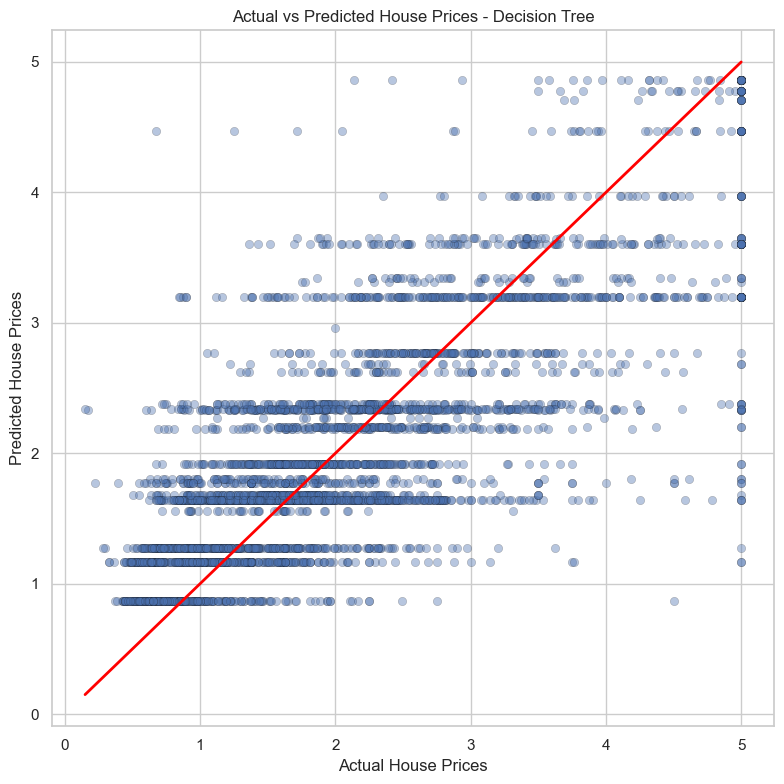

In [8]:
best_model_name = results_df["RMSE"].idxmin()
best_model = models[best_model_name]
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.4, edgecolor="k", linewidth=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linewidth=2)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title(f"Actual vs Predicted House Prices - {best_model_name}")
plt.tight_layout()
plt.show()

## 9. Final Model Selection and Justification

In [9]:
best_model_name, best_model_metrics = '', {}
best_model_name = results_df["RMSE"].idxmin()
best_model_metrics = results_df.loc[best_model_name].to_dict()
print("Best model selected:", best_model_name)
print("RMSE:", round(best_model_metrics["RMSE"], 3))
print("R2 Score:", round(best_model_metrics["R2 Score"], 3))

Best model selected: Decision Tree
RMSE: 0.724
R2 Score: 0.6


The best model is selected based on the lowest RMSE and the highest R² among the candidates. This model provides the strongest predictive performance on the test set while minimizing error.

## 10. Optional: Save the Best Model

In [10]:
model_filename = "best_house_price_model.joblib"
dump(best_model, model_filename)
print("Saved best model to:", model_filename)

Saved best model to: best_house_price_model.joblib


## 11. Summary

- Loaded California Housing dataset
- Scaled input features using StandardScaler
- Trained Linear Regression, Ridge Regression, and Decision Tree models
- Compared performance using RMSE and R²
- Selected the best performing model and saved it for reuse.